In [3]:
11

11

In [4]:
import os
import random
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Any
import sentencepiece as spm

import evaluate
import numpy as np
import torch
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets, disable_progress_bar
from transformers import (
    pipeline,
    MBart50TokenizerFast,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.trainer_utils import get_last_checkpoint

2025-11-02 21:07:15.722219: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-02 21:07:15.931679: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 21:07:17.598365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
# Replace with your HuggingFace dataset name
DATASET_NAME = "pollitoconpapass/spanish_2_shipibo_konibo"
# Adjust these if your dataset has different column names
SOURCE_COLUMN = "shp"  # or "shipibo"
TARGET_COLUMN = "spa"   # or "spanish"


SPA_MODEL_NAME = "pysentimiento/robertuito-sentiment-analysis"
SPA_MODEL_LOCAL_PATH = "models/pysentimiento/robertuito-sentiment-analysis"
SPA_TOKENIZER_NAME = "pysentimiento/robertuito-sentiment-analysis"
SPA_TOKENIZER_LOCAL_PATH = "models/pysentimiento/robertuito-sentiment-analysis"


BASE_MODEL_NAME = "xlm-roberta-base"
BASE_MODEL_LOCAL_PATH = "models/xlm-roberta-base"
BASE_TOKENIZER_NAME = "xlm-roberta-base"
BASE_TOKENIZER_LOCAL_PATH = "tokenizers/xlm-roberta-base"  # Assuming tokenizer is saved with the model

TRAINED_MODEL_NAME = "bert-sentiment-shipibo"
TRAINED_MODEL_OUTPUT_DIR = f"models/bert-sentiment-shipibo"
TRAINED_MODEL_LOGS_DIR = f"logs/bert-sentiment-shipibo"

CONFIDENCE_THRESHOLD = 0.6

In [6]:
def clear_gpu_memory():
    """Clear GPU memory cache"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        import gc
        gc.collect()
        print("🧹 GPU memory cleared")

In [7]:
print(f"📊 Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

📊 Device: GPU
   GPU: NVIDIA GeForce RTX 4070 Ti SUPER
   Memory: 17.17 GB


In [8]:
def load_shipibo_dataset(dataset_name: str) -> DatasetDict:
    """
    Load Shipibo-Spanish parallel corpus from HuggingFace
    
    Args:
        dataset_name: HuggingFace dataset identifier (e.g., "username/dataset-name")
    
    Returns:
        DatasetDict with train/validation/test splits
    """
    print(f"\n📥 Loading dataset: {dataset_name}")
    
    # Load the dataset
    dataset = load_dataset(dataset_name)
    
    # Display statistics
    print("\n📊 Dataset Statistics:")
    for split in dataset.keys():
        print(f"   {split}: {len(dataset[split])} examples")
        if len(dataset[split]) > 0:
            # Show first example
            example = dataset[split][0]
            print(f"   Example Shipibo: {example.get('shp', example.get('shipibo', 'N/A'))[:50]}...")
            print(f"   Example Spanish: {example.get('spa', example.get('spanish', 'N/A'))[:50]}...")
    
    return dataset


In [9]:
def prepare_tokenizer(tokenizer_path: str, source_key: str, target_key: str) -> AutoTokenizer:
    """
    Load and configure mBART-50 tokenizer for Shipibo→Spanish
    """
    print("\n🔧 Loading mBART-50 tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        
    return tokenizer

In [10]:
def prepare_sentiment_model(model_name: str, model_path: str):
    """
    Get the pre-trained model locally.
    
    Args:
        model_name: Name of the pre-trained model to download.
        model_path: Directory where the model is saved.
    """
    print(f"\n⬇️  Loading model: {model_name}")
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.config.label2id = {'NEG': 0, 'NEU': 1, 'POS': 2}
    model.config.id2label = {0: 'NEG', 1: 'NEU', 2: 'POS'}
    print(f"   Model loaded from: {model_path}")
    return model
    

In [11]:
def download_sentiment_model(model_name: str, output_dir: str):
    """
    Download and save the pre-trained model locally.
    
    Args:
        model_name: Name of the pre-trained model to download.
        output_dir: Directory to save the downloaded model.
    """
    print(f"\n⬇️  Downloading model: {model_name}")
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.save_pretrained(output_dir)
    print(f"   Model saved to: {output_dir}")

In [12]:
def download_tokenizer(tokenizer_name: str, output_dir: str):
    """
    Download and save the tokenizer locally.
    
    Args:
        tokenizer_name: Name of the tokenizer to download.
        output_dir: Directory to save the downloaded tokenizer.
    """
    print(f"\n⬇️  Downloading tokenizer: {tokenizer_name}")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    tokenizer.save_pretrained(output_dir)
    print(f"   Tokenizer saved to: {output_dir}")

In [21]:

def project_labels(parallel_corpus: Dataset, model: AutoModelForSequenceClassification, tokenizer: AutoTokenizer, threshold: float, output_path: str = "") -> Dataset:
    """
    Project sentiment labels from Spanish to Shipibo using a Spanish sentiment model to predict sentiment scores and then project them into the parallel corpus.

    Args:
        parallel_corpus: The parallel corpus containing Spanish and Shipibo text.
        model: The Spanish sentiment model used for prediction.
        tokenizer: The tokenizer corresponding to the sentiment model.
    Returns:
        A dataset containing sentiment labels with alligned parallel sentences. (shipibo, spanish, sentiment_label)
    """

    def predict_labels(texts: List[str]) -> List[Dict]:
        """Predict sentiment label for given Spanish text. Returns both label and score."""
        pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
        result = pipe(texts)
        return result

    # Predict labels for each Spanish sentence in the parallel corpus
    predicted_labels = []
    predicted_scores = []
    
    # Batch process Spanish texts
    for i in tqdm(range(0, len(parallel_corpus), 1000)):
        batch = parallel_corpus[i:i+1000]['spa']
        results = predict_labels(batch)
        for item in results:
            predicted_labels.append(item['label'])
            predicted_scores.append(item['score'])
            
    parallel_corpus = parallel_corpus.add_column("sentiment_label", predicted_labels)
    parallel_corpus = parallel_corpus.add_column("sentiment_score", predicted_scores)

    # Apply confidence threshold
    parallel_corpus = parallel_corpus.filter(lambda x: x['sentiment_score'] >= threshold)

    # If output_path is specified, save the projected dataset
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        parallel_corpus.to_parquet(output_path)
        print(f"\n💾 Projected dataset saved to: {output_path}")
    return parallel_corpus

## Project Labels

In [14]:
# Download dataset
dataset = load_shipibo_dataset(DATASET_NAME)


📥 Loading dataset: pollitoconpapass/spanish_2_shipibo_konibo

📊 Dataset Statistics:
   train: 24144 examples
   Example Shipibo: Nokawe....
   Example Spanish: Apágalo....
   validation: 3018 examples
   Example Shipibo: píarebo....
   Example Spanish: punta de flecha....
   test: 3018 examples
   Example Shipibo: Kirikanin non raoki ika rabiti wishaxon axetixobon...
   Example Spanish: Escribe en un cuaderno un poema a nuestras plantas...


In [15]:
# Download Spanish model and tokenizer if not already present
if not os.path.exists(SPA_MODEL_LOCAL_PATH):
    download_sentiment_model(SPA_MODEL_NAME, SPA_MODEL_LOCAL_PATH)
spa_model = prepare_sentiment_model(SPA_MODEL_NAME, SPA_MODEL_LOCAL_PATH)
if not os.path.exists(SPA_TOKENIZER_LOCAL_PATH):
    download_tokenizer(SPA_TOKENIZER_NAME, SPA_TOKENIZER_LOCAL_PATH)
spa_tokenizer = prepare_tokenizer(SPA_TOKENIZER_NAME, SOURCE_COLUMN, TARGET_COLUMN)


⬇️  Loading model: pysentimiento/robertuito-sentiment-analysis
   Model loaded from: models/pysentimiento/robertuito-sentiment-analysis

🔧 Loading mBART-50 tokenizer...


In [16]:
# Project spanish dataset sentiment labels to shipibo
project_dataset = dataset['train']
projected_dataset = project_labels(project_dataset, spa_model, spa_tokenizer, CONFIDENCE_THRESHOLD)
print(f"\n📊 Projected dataset size: {len(projected_dataset)} examples")

100%|██████████| 25/25 [02:14<00:00,  5.36s/it]


📊 Projected dataset size: 16505 examples


In [17]:
projected_dataset = projected_dataset.to_pandas()
projected_dataset

,spa,shp,__index_level_0__,sentiment_label,sentiment_score
0,Ahora hazles recordar a través de diferentes p...,Jato shinamawe mesko yokabo axon neskaakin.,24269,NEU,0.786801
1,Eso pensaba.,Jaskara en shinainbake.,20089,NEU,0.602634
2,¿Estás mejor Tomas?,¿Jakontanirin mia tomas?,16947,NEU,0.653322
3,Mamá hizo descolorar mi camisa poniéndola todo...,Nocon cotón titán nétetibi barínco acára manxá...,2254,NEU,0.689159
4,¿Estás coqueteando conmigo?,¿Ebe shirokasirin mia?,7303,NEU,0.730224
...,...,...,...,...,...
16500,Baleé al maquisapa con una escopeta.,Tóoatinra en íso tóoaque.,29802,NEG,0.612607
16501,Siéntate con los niños en el suelo y entrégale...,Bakebo naman yakakinxon ja tee akanabo bexon j...,5390,POS,0.834070
16502,Este niño está echado de espaldas porque su ma...,Nato báquera catsáque jahuen titán joíntiqui r...,860,NEG,0.966792
16503,Un momentito.,Ea manawe.,15795,NEU,0.631376


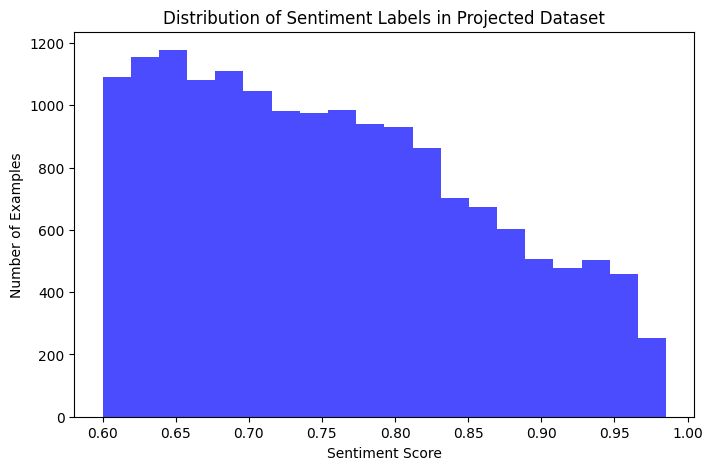

In [18]:
# Plot distribution of sentiment scores in projected_dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(projected_dataset["sentiment_score"], bins=20, color='blue', alpha=0.7)
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Examples')
plt.title('Distribution of Sentiment Labels in Projected Dataset')
plt.show()                                                

In [23]:
projected_dataset.to_parquet("projected_datasets/train.parquet")

In [22]:
# Project test and validation
projected_test = project_labels(dataset['test'], spa_model, spa_tokenizer, CONFIDENCE_THRESHOLD, output_path="projected_datasets/test.parquet")
projected_validation = project_labels(dataset['validation'], spa_model, spa_tokenizer, CONFIDENCE_THRESHOLD, output_path="projected_datasets/validation.parquet")

100%|██████████| 4/4 [00:17<00:00,  4.28s/it]


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]


💾 Projected dataset saved to: projected_datasets/test


100%|██████████| 4/4 [00:17<00:00,  4.28s/it]


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]


💾 Projected dataset saved to: projected_datasets/validation
